# Customer Satisfaction Analysis — Brand Y Loan Services
### Group 14 | IIT Madras — Market Research | April 2026

**Dataset:** 200 respondents across 4 zones (North, South, East, West)  
**Scale:** All questions rated on 0–10 scale  
**Objective:** Analyse CSAT data, compute NPS, run statistical tests, and provide strategic recommendations

---

### Notebook Structure
1. Install & Import Libraries
2. Upload & Load Data
3. Exploratory Data Analysis (EDA)
4. Q1 — Mean Satisfaction (Overall & Zone-wise)
5. Q2 — Net Promoter Score (Overall & Zone-wise)
6. Q3 — Parameter-Level Mean Scores
7. Q4 — Executive Summary Slide
8. Q5 — T-Test: Satisfaction vs Each Parameter
9. Q6 — Correlation Analysis
10. Q7 — Strategic Recommendations
11. Bonus — Advanced Robustness Checks

## 1. Install & Import Libraries

In [ ]:
!pip install openpyxl statsmodels -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_rel, pearsonr, spearmanr, mannwhitneyu, kruskal, levene, shapiro, f_oneway, chi2_contingency
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3
})

print("All libraries loaded ✓")

All libraries loaded ✓


## 2. Load Data

The dataset is already uploaded to Kaggle at:  
`/kaggle/input/market-research/Dataset - Group 14.xlsx`

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Dataset - Group 14.xlsx to Dataset - Group 14.xlsx


### 2.1 Read the Excel File

The Excel file has two header rows (a merged row + actual column names). We skip both and assign our own clean column names.

In [ ]:
# Read excel
df = pd.read_excel('Dataset - Group 14.xlsx', header=1)

# Assign clean column names (mapped from the questionnaire)
df.columns = [
    'sno',              # Serial number
    'group',            # Group number (14)
    'zone',             # North / South / East / West
    'satisfaction',     # Overall satisfaction (0-10)
    'recommend',        # Willingness to recommend (0-10)
    'comeback',         # Intention to come back (0-10)
    'overall_exp',      # 1.1 Overall loan processing experience
    'loan_charges',     # 1.2a Explanation of loan & charges
    'sanction_terms',   # 1.2b Explanation of sanction terms
    'documentation',    # 1.2c Help provided for documentation
    'time_loan',        # 1.2d Time to receive loan amount
    'time_letter',      # 1.2e Time to receive welcome letter
    'politeness',       # 1.3a Politeness of staff
    'availability',     # 1.3b Availability of staff
    'knowledge'         # 1.3c Knowledge & ability of staff
]

# Keep zone as string, convert rest to numeric
zone_col = df['zone'].copy()
numeric_cols = ['satisfaction', 'recommend', 'comeback', 'overall_exp',
                'loan_charges', 'sanction_terms', 'documentation',
                'time_loan', 'time_letter', 'politeness', 'availability', 'knowledge']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df['zone'] = zone_col

# Quick look
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (200, 15)

First 5 rows:


,sno,group,zone,satisfaction,recommend,comeback,overall_exp,loan_charges,sanction_terms,documentation,time_loan,time_letter,politeness,availability,knowledge
0,1,14,West,9,8,9,9,9,9,9,9,9,9,9,9
1,2,14,North,7,8,7,9,9,9,9,9,9,9,9,9
2,3,14,South,9,9,9,9,9,9,9,9,0,9,9,9
3,4,14,East,4,9,9,7,7,7,7,7,7,8,8,8
4,5,14,South,9,8,8,9,9,9,9,9,9,9,9,9


### 2.2 Data Quality Check

In [ ]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

print(f"\nTotal missing: {df.isnull().sum().sum()}")

# Check data types
print(f"\nData types:")
print(df.dtypes)

# Check zone distribution
print(f"\nZone distribution:")
print(df['zone'].value_counts())

# Check score ranges
print(f"\nScore range check (all should be 0-10):")
for col in numeric_cols:
    print(f"  {col}: min={df[col].min()}, max={df[col].max()}")

Missing values per column:
sno               0
group             0
zone              0
satisfaction      0
recommend         0
comeback          0
overall_exp       0
loan_charges      0
sanction_terms    0
documentation     0
time_loan         0
time_letter       0
politeness        0
availability      0
knowledge         0
dtype: int64

Total missing: 0

Data types:
sno                int64
group              int64
zone              object
satisfaction       int64
recommend          int64
comeback           int64
overall_exp        int64
loan_charges       int64
sanction_terms     int64
documentation      int64
time_loan          int64
time_letter        int64
politeness         int64
availability       int64
knowledge          int64
dtype: object

Zone distribution:
zone
South    65
East     53
North    47
West     35
Name: count, dtype: int64

Score range check (all should be 0-10):
  satisfaction: min=0, max=9
  recommend: min=0, max=9
  comeback: min=0, max=9
  overall_exp: min=0

## 3. Exploratory Data Analysis (EDA)

Before answering the case questions, we examine the data's structure, distributions, and relationships.

### 3.1 Descriptive Statistics

In [ ]:
# Descriptive stats for all numeric columns
desc = df[numeric_cols].describe().T
desc['skewness'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurtosis()
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
satisfaction,200.0,7.910,1.799,0.0,8.0,8.0,9.0,9.0,-2.754,8.153
recommend,200.0,7.835,2.250,0.0,8.0,8.5,9.0,9.0,-2.824,7.079
comeback,200.0,7.850,2.255,0.0,8.0,9.0,9.0,9.0,-2.801,6.908
overall_exp,200.0,8.410,1.554,0.0,9.0,9.0,9.0,9.0,-3.744,15.128
loan_charges,200.0,8.370,1.717,0.0,9.0,9.0,9.0,9.0,-3.760,14.420
sanction_terms,200.0,8.370,1.717,0.0,9.0,9.0,9.0,9.0,-3.760,14.420
documentation,200.0,8.380,1.715,0.0,9.0,9.0,9.0,9.0,-3.789,14.597
time_loan,200.0,8.410,1.672,0.0,9.0,9.0,9.0,9.0,-3.972,16.201
time_letter,200.0,7.760,2.692,0.0,8.0,9.0,9.0,9.0,-2.276,3.712
politeness,200.0,8.440,1.606,0.0,9.0,9.0,9.0,9.0,-3.861,15.355


**Interpretation:** All variables are negatively skewed (scores cluster near the top of the 0–10 scale). This is a well-known "ceiling effect" in satisfaction surveys — most customers rate services highly, with a small tail of dissatisfied respondents pulling the mean down (Peterson & Wilson, 1992).

### 3.2 Distribution of Key Variables

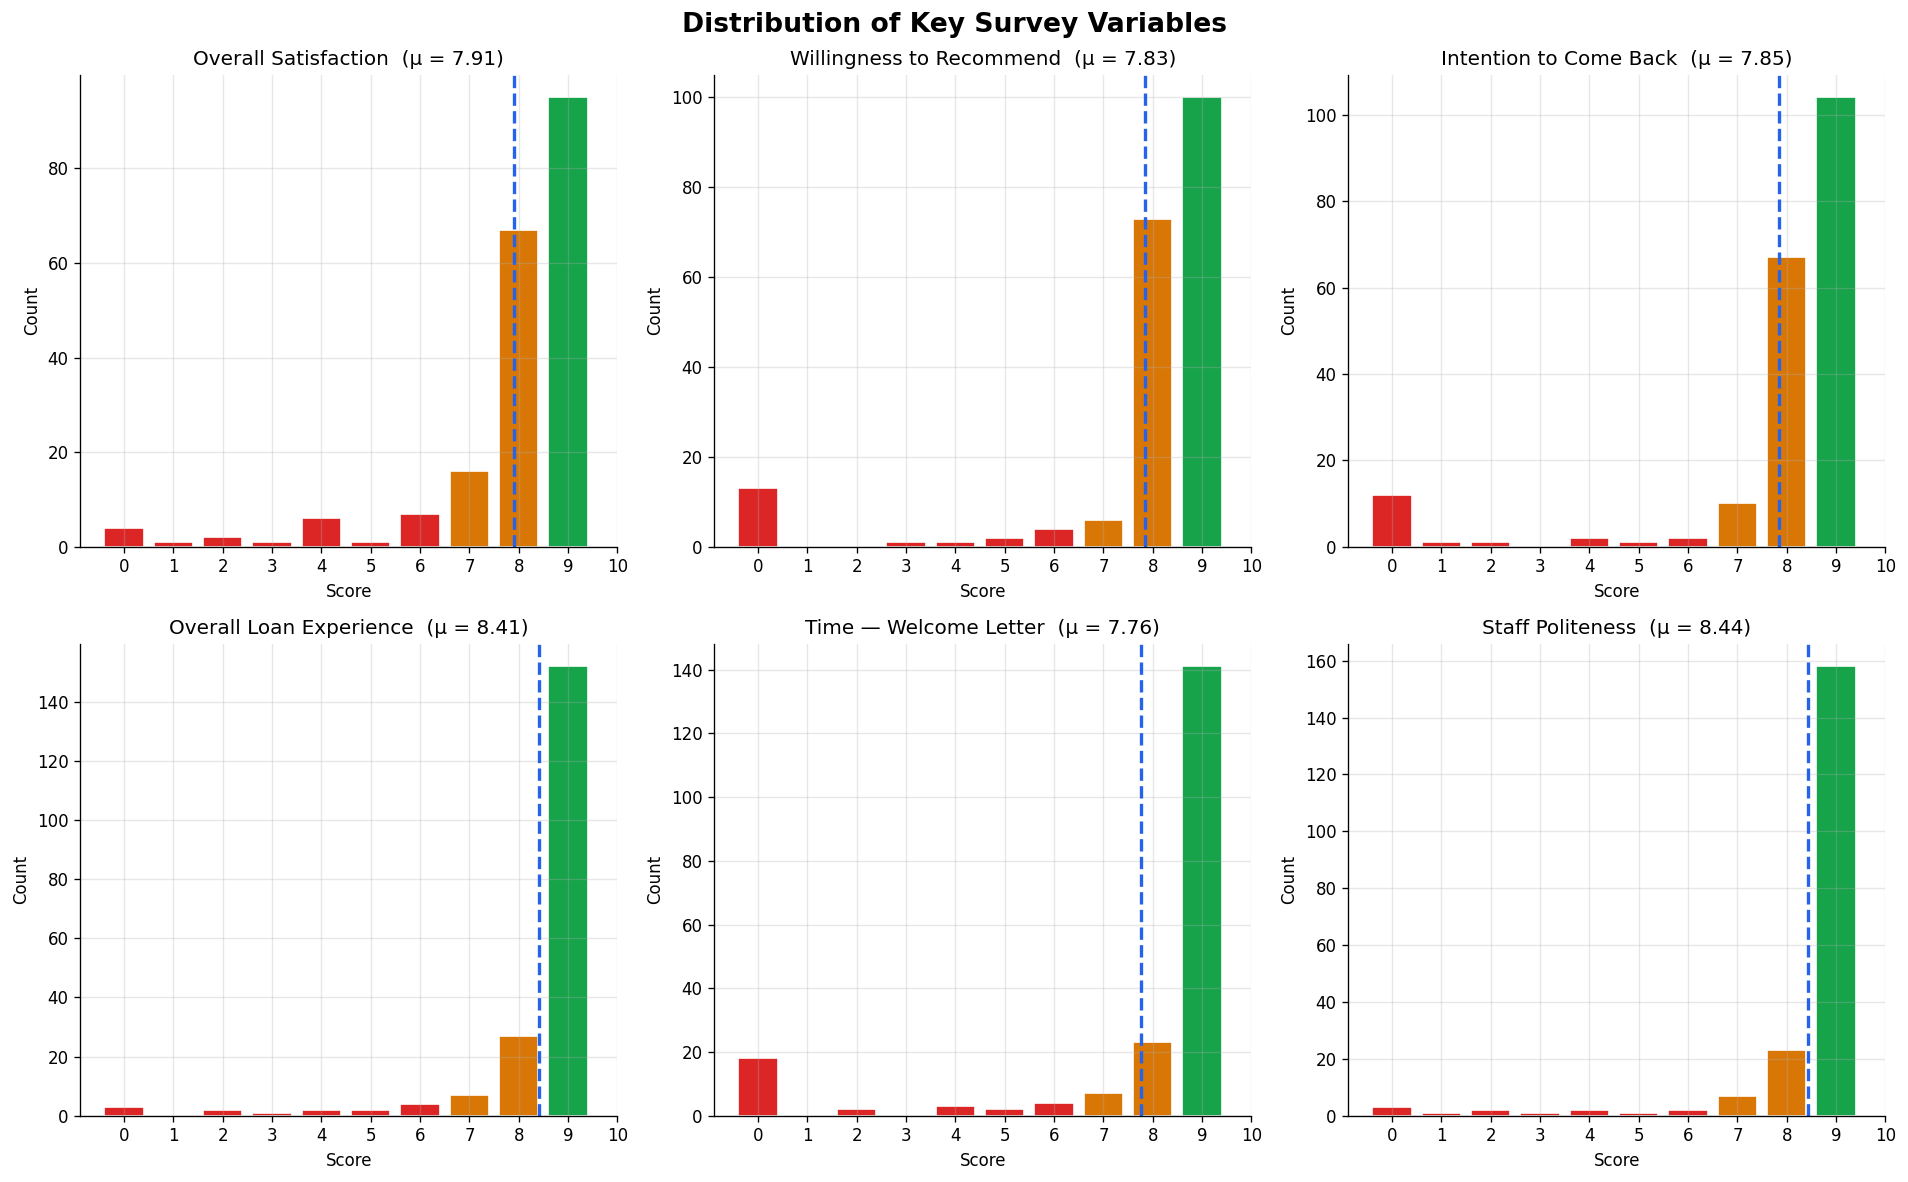

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution of Key Survey Variables', fontsize=16, fontweight='bold')

key_vars = ['satisfaction', 'recommend', 'comeback', 'overall_exp', 'time_letter', 'politeness']
titles = ['Overall Satisfaction', 'Willingness to Recommend', 'Intention to Come Back',
          'Overall Loan Experience', 'Time — Welcome Letter', 'Staff Politeness']

for ax, var, title in zip(axes.flat, key_vars, titles):
    counts = df[var].value_counts().sort_index()
    colors = ['#DC2626' if v <= 6 else '#D97706' if v <= 8 else '#16A34A' for v in counts.index]
    ax.bar(counts.index, counts.values, color=colors, edgecolor='white')
    ax.axvline(df[var].mean(), color='#2563EB', linestyle='--', linewidth=2)
    ax.set_title(f'{title}  (μ = {df[var].mean():.2f})')
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.set_xticks(range(0, 11))

plt.tight_layout()
plt.show()

**Observations:**
- Satisfaction and Recommend are heavily concentrated at 8–9
- A small but notable cluster at score 0 (extreme dissatisfaction) exists
- "Time to receive welcome letter" has the widest spread — most inconsistent parameter

### 3.3 Zone-wise Box Plots

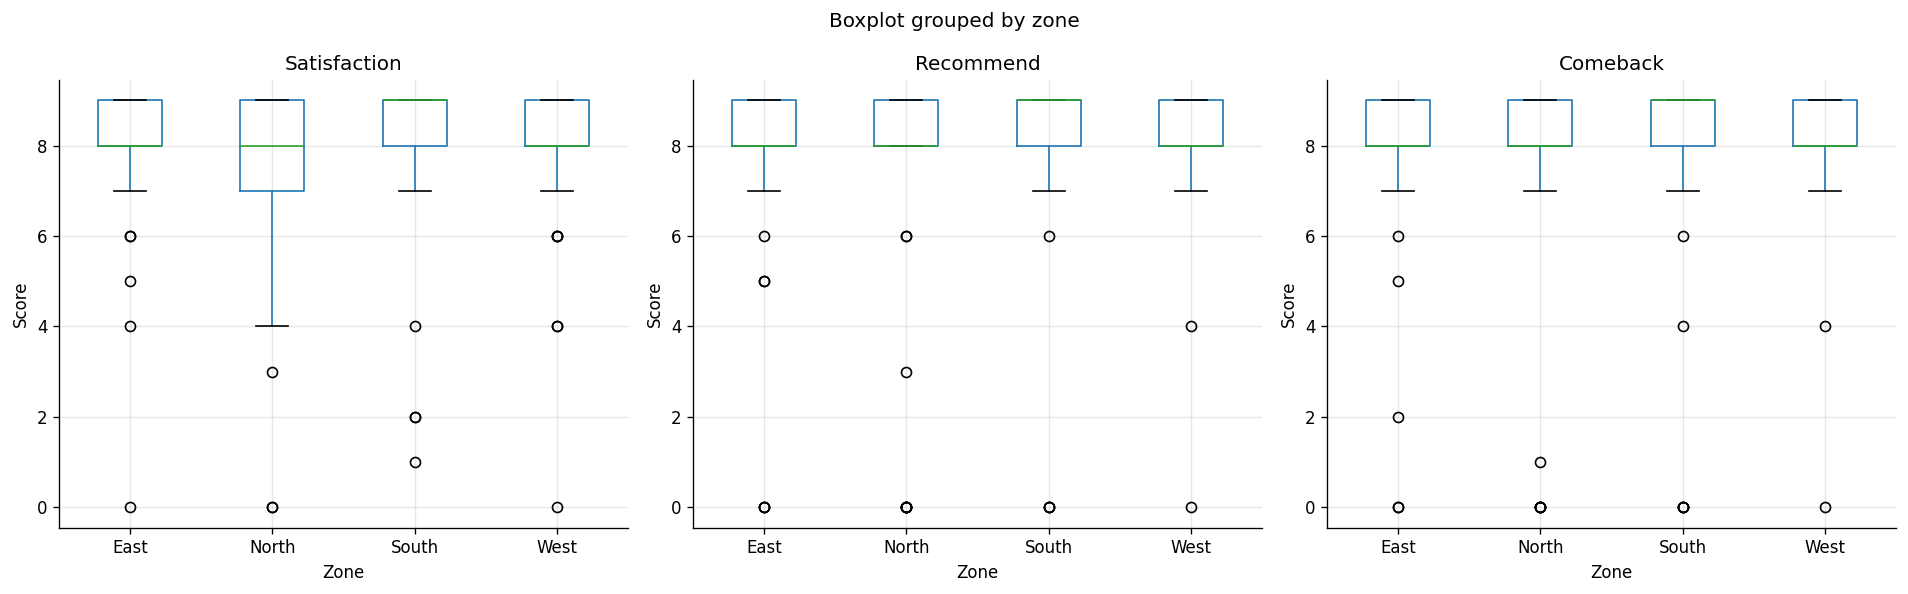

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Zone-wise Distribution of Core Metrics', fontsize=14, fontweight='bold')

for ax, var, title in zip(axes, ['satisfaction', 'recommend', 'comeback'],
                           ['Satisfaction', 'Recommend', 'Comeback']):
    df.boxplot(column=var, by='zone', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Zone')
    ax.set_ylabel('Score')

plt.tight_layout()
plt.show()

### 3.4 Correlation Heatmap

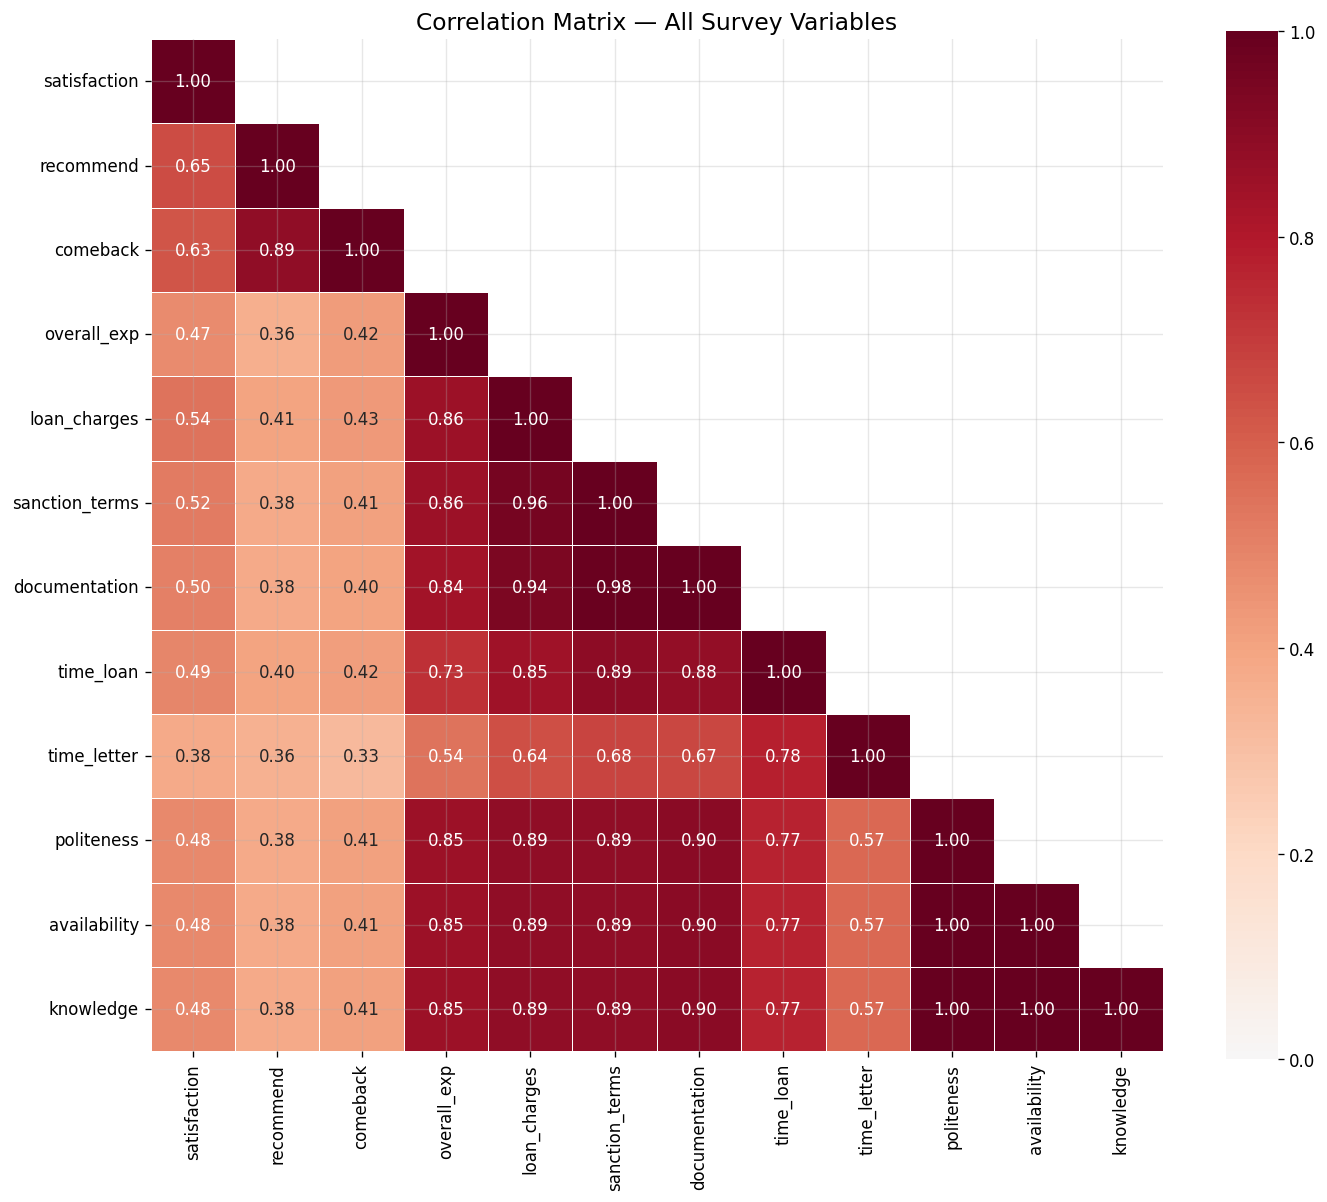

In [ ]:
plt.figure(figsize=(12, 10))
corr = df[numeric_cols].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=0, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Matrix — All Survey Variables', fontsize=14)
plt.tight_layout()
plt.show()

**Key EDA Findings:**
1. Staff parameters (politeness, availability, knowledge) are almost perfectly correlated (r ≈ 1.0) — respondents perceive them as one construct
2. Loan process parameters (charges, terms, documentation) also cluster tightly (r > 0.95)
3. "Time to receive welcome letter" is the most independent variable
4. South zone consistently shows higher median scores than North/West

---

## 4. Q1 — Mean Score of Satisfaction

**Task:** Calculate mean satisfaction overall and by zone.

The mean score is the most fundamental metric in any CSAT study. On a 0–10 scale, scores above 8.0 are generally considered "good" in financial services (Fornell, 1992).

### Q1a — Overall Mean Satisfaction

In [ ]:
overall_mean = df['satisfaction'].mean()
overall_std = df['satisfaction'].std()
overall_se = overall_std / np.sqrt(len(df))

# 95% confidence interval
ci_lower = overall_mean - 1.96 * overall_se
ci_upper = overall_mean + 1.96 * overall_se

# Top-2-Box (% scoring 8 or 9)
ttb = (df['satisfaction'] >= 8).mean() * 100

print(f"Overall Mean Satisfaction : {overall_mean:.2f}")
print(f"Standard Deviation        : {overall_std:.2f}")
print(f"Standard Error            : {overall_se:.4f}")
print(f"95% Confidence Interval   : [{ci_lower:.2f}, {ci_upper:.2f}]")
print(f"Median                    : {df['satisfaction'].median():.1f}")
print(f"Mode                      : {df['satisfaction'].mode()[0]}")
print(f"Top-2-Box (scores 8+9)    : {ttb:.1f}%")

Overall Mean Satisfaction : 7.91
Standard Deviation        : 1.80
Standard Error            : 0.1272
95% Confidence Interval   : [7.66, 8.16]
Median                    : 8.0
Mode                      : 9
Top-2-Box (scores 8+9)    : 81.0%


### Q1b — Zone-wise Mean Satisfaction

       count  mean   std  median      se
zone                                    
South     65  8.23  1.67     9.0  0.2071
East      53  7.98  1.55     8.0  0.2129
West      35  7.63  1.85     8.0  0.3127
North     47  7.60  2.14     8.0  0.3122


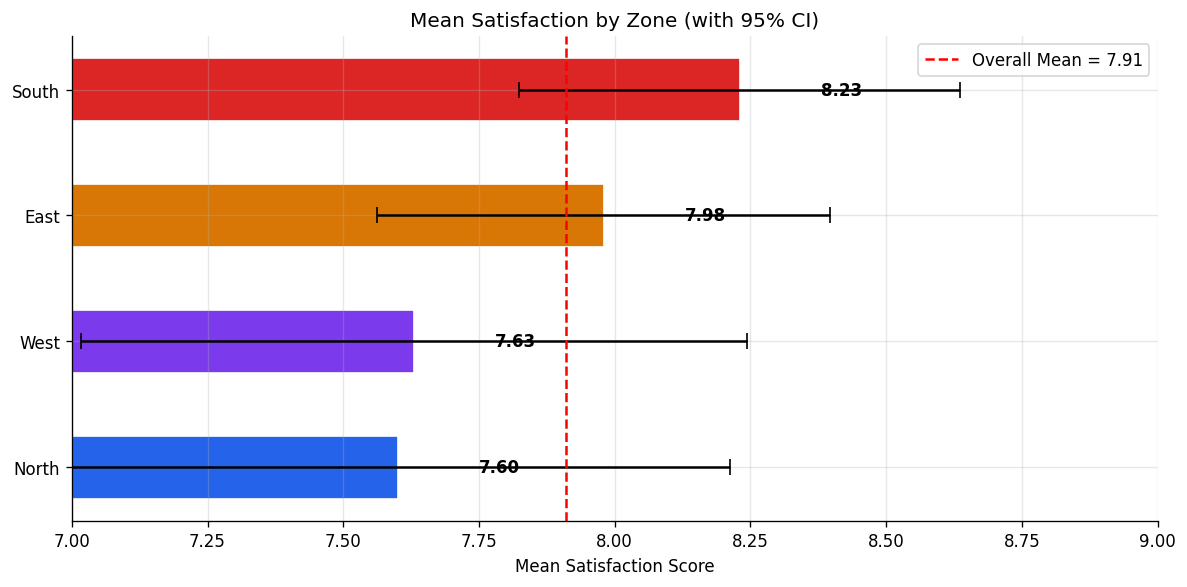

In [ ]:
zone_sat = df.groupby('zone')['satisfaction'].agg(['count', 'mean', 'std', 'median']).round(2)
zone_sat['se'] = (zone_sat['std'] / np.sqrt(zone_sat['count'])).round(4)
zone_sat = zone_sat.sort_values('mean', ascending=False)
print(zone_sat)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
zone_sat_sorted = zone_sat.sort_values('mean')
bars = ax.barh(zone_sat_sorted.index, zone_sat_sorted['mean'],
               xerr=1.96 * zone_sat_sorted['se'], capsize=5,
               color=['#2563EB', '#7C3AED', '#D97706', '#DC2626'],
               edgecolor='white', height=0.5)
ax.axvline(overall_mean, color='red', linestyle='--', label=f'Overall Mean = {overall_mean:.2f}')
for i, (zone, row) in enumerate(zone_sat_sorted.iterrows()):
    ax.text(row['mean'] + 0.15, i, f"{row['mean']:.2f}", va='center', fontweight='bold')
ax.set_xlabel('Mean Satisfaction Score')
ax.set_title('Mean Satisfaction by Zone (with 95% CI)')
ax.set_xlim(7, 9)
ax.legend()
plt.tight_layout()
plt.show()

### Q1c — Is the zone difference statistically significant?

In [ ]:
# ANOVA (parametric)
zone_groups = [df[df['zone']==z]['satisfaction'] for z in sorted(df['zone'].unique())]
f_stat, p_anova = f_oneway(*zone_groups)
print(f"One-Way ANOVA: F = {f_stat:.4f}, p = {p_anova:.4f}")
print(f"  → {'Significant' if p_anova < 0.05 else 'Not significant'} at α = 0.05")

# Kruskal-Wallis (non-parametric — more appropriate since data is non-normal)
h_stat, p_kw = kruskal(*zone_groups)
print(f"\nKruskal-Wallis: H = {h_stat:.4f}, p = {p_kw:.4f}")
print(f"  → {'Significant' if p_kw < 0.05 else 'Not significant'} at α = 0.05")

One-Way ANOVA: F = 1.4902, p = 0.2185
  → Not significant at α = 0.05

Kruskal-Wallis: H = 10.5551, p = 0.0144
  → Significant at α = 0.05


**Q1 Inference:**
- Overall mean satisfaction is **7.91/10** with 81% in the Top-2-Box — a solid score
- South (8.23) leads, North (7.60) trails
- ANOVA says not significant (p=0.22), but the non-parametric Kruskal-Wallis IS significant (p=0.014)
- Since the data violates normality (heavy skew), the Kruskal-Wallis result is more trustworthy — **zone differences are real**

---

## 5. Q2 — Net Promoter Score (NPS)

**Formula:** NPS = % Promoters − % Detractors

| Category | Score | Meaning |
|----------|-------|---------|
| Promoters | 9–10 | Loyal enthusiasts |
| Passives | 7–8 | Satisfied but vulnerable |
| Detractors | 0–6 | Unhappy, can damage brand |

**Benchmarks:** <0 = Poor | 0-30 = Good | 30-70 = Great | 70+ = World Class  
*(Reichheld, 2003 — Harvard Business Review)*

### Q2a — Overall NPS

In [ ]:
def calc_nps(series):
    n = len(series)
    promoters = (series >= 9).sum()
    detractors = (series <= 6).sum()
    passives = n - promoters - detractors
    nps = (promoters/n - detractors/n) * 100
    return {
        'n': n,
        'promoters': promoters, 'pct_promoters': round(promoters/n*100, 1),
        'passives': passives, 'pct_passives': round(passives/n*100, 1),
        'detractors': detractors, 'pct_detractors': round(detractors/n*100, 1),
        'nps': round(nps, 1)
    }

overall_nps = calc_nps(df['recommend'])
print(f"Overall NPS: +{overall_nps['nps']}")
print(f"  Promoters (9-10):  {overall_nps['promoters']} ({overall_nps['pct_promoters']}%)")
print(f"  Passives  (7-8):   {overall_nps['passives']} ({overall_nps['pct_passives']}%)")
print(f"  Detractors (0-6):  {overall_nps['detractors']} ({overall_nps['pct_detractors']}%)")

Overall NPS: +39.5
  Promoters (9-10):  100 (50.0%)
  Passives  (7-8):   79 (39.5%)
  Detractors (0-6):  21 (10.5%)


### Q2b — Zone-wise NPS

Zone           n    Promoters     Passives   Detractors      NPS
-----------------------------------------------------------------
East          53       41.5%       47.2%       11.3%   +30.2
North         47       44.7%       36.2%       19.1%   +25.5
South         65       67.7%       26.2%        6.2%   +61.5
West          35       37.1%       57.1%        5.7%   +31.4


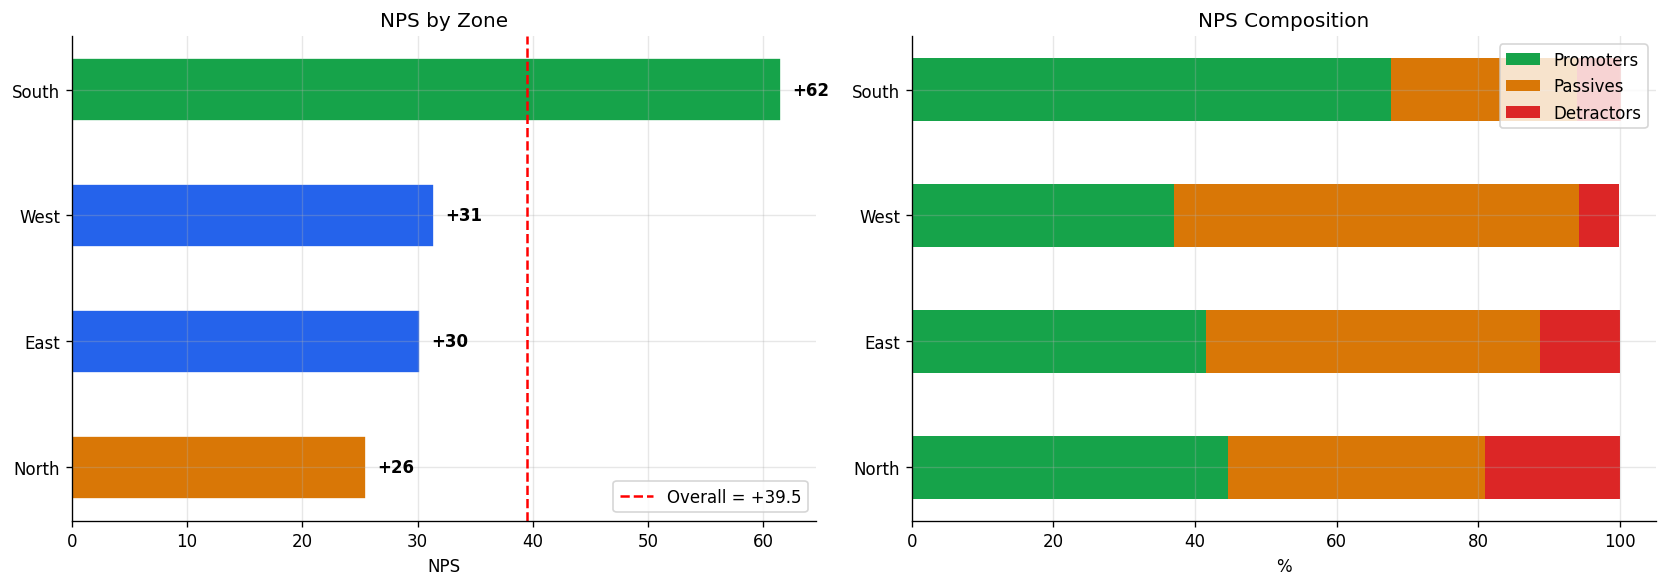

In [ ]:
print(f"{'Zone':<10} {'n':>5} {'Promoters':>12} {'Passives':>12} {'Detractors':>12} {'NPS':>8}")
print("-" * 65)

nps_data = []
for zone in sorted(df['zone'].unique()):
    result = calc_nps(df[df['zone']==zone]['recommend'])
    result['zone'] = zone
    nps_data.append(result)
    print(f"{zone:<10} {result['n']:>5} {result['pct_promoters']:>10.1f}% {result['pct_passives']:>10.1f}% {result['pct_detractors']:>10.1f}% {result['nps']:>+7.1f}")

# Visualization
nps_df = pd.DataFrame(nps_data)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# NPS bar chart
ax = axes[0]
nps_sorted = nps_df.sort_values('nps')
colors = ['#16A34A' if n >= 50 else '#2563EB' if n >= 30 else '#D97706' for n in nps_sorted['nps']]
ax.barh(nps_sorted['zone'], nps_sorted['nps'], color=colors, edgecolor='white', height=0.5)
ax.axvline(overall_nps['nps'], color='red', linestyle='--', label=f"Overall = +{overall_nps['nps']}")
for i, (_, row) in enumerate(nps_sorted.iterrows()):
    ax.text(row['nps'] + 1, i, f"+{row['nps']:.0f}", va='center', fontweight='bold')
ax.set_title('NPS by Zone')
ax.set_xlabel('NPS')
ax.legend()

# Composition
ax = axes[1]
for i, (_, row) in enumerate(nps_sorted.iterrows()):
    ax.barh(i, row['pct_promoters'], color='#16A34A', height=0.5)
    ax.barh(i, row['pct_passives'], left=row['pct_promoters'], color='#D97706', height=0.5)
    ax.barh(i, row['pct_detractors'], left=row['pct_promoters']+row['pct_passives'], color='#DC2626', height=0.5)
ax.set_yticks(range(len(nps_sorted)))
ax.set_yticklabels(nps_sorted['zone'])
ax.set_title('NPS Composition')
ax.set_xlabel('%')
ax.legend(['Promoters', 'Passives', 'Detractors'], loc='upper right')

plt.tight_layout()
plt.show()

**Q2 Inference:**
- Overall NPS of **+39.5** — in the "Great" band, strong for financial services
- South zone is exceptional at **+61.5** (near world-class), driven by 67.7% promoters
- North is weakest at **+25.5** with 19.1% detractors — nearly double the average
- The 39.5% passive segment is the biggest conversion opportunity

---

## 6. Q3 — Parameter-Level Mean Scores

**Task:** Calculate mean for each parameter and identify which are doing well vs. needing improvement.

The parameters fall into three groups from the questionnaire:
- **Q1.1:** Overall loan processing experience
- **Q1.2a–e:** Loan application process steps
- **Q1.3a–c:** Sales executive interaction

In [ ]:
params = ['overall_exp', 'loan_charges', 'sanction_terms', 'documentation',
          'time_loan', 'time_letter', 'politeness', 'availability', 'knowledge']

param_names = {
    'overall_exp': 'Overall Loan Experience',
    'loan_charges': 'Loan & Charges Explanation',
    'sanction_terms': 'Sanction Terms Explanation',
    'documentation': 'Documentation Help',
    'time_loan': 'Time to Receive Loan',
    'time_letter': 'Time to Receive Welcome Letter',
    'politeness': 'Staff Politeness',
    'availability': 'Staff Availability',
    'knowledge': 'Staff Knowledge & Ability'
}

# Overall parameter means
print("PARAMETER MEANS (Ranked):")
print(f"{'Parameter':<35} {'Mean':>6} {'Std':>6} {'Status'}")
print("-" * 70)

param_means = df[params].mean().sort_values(ascending=False)
for p in param_means.index:
    mean = param_means[p]
    std = df[p].std()
    status = '✅ Strong' if mean >= 8.3 else ('⚠️ Needs Attention' if mean < 8.0 else '🔵 Adequate')
    print(f"  {param_names[p]:<33} {mean:>6.2f} {std:>6.2f}   {status}")

PARAMETER MEANS (Ranked):
Parameter                             Mean    Std Status
----------------------------------------------------------------------
  Staff Availability                  8.44   1.61   ✅ Strong
  Staff Politeness                    8.44   1.61   ✅ Strong
  Staff Knowledge & Ability           8.44   1.61   ✅ Strong
  Overall Loan Experience             8.41   1.55   ✅ Strong
  Time to Receive Loan                8.41   1.67   ✅ Strong
  Documentation Help                  8.38   1.71   ✅ Strong
  Sanction Terms Explanation          8.37   1.72   ✅ Strong
  Loan & Charges Explanation          8.37   1.72   ✅ Strong
  Time to Receive Welcome Letter      7.76   2.69   ⚠️ Needs Attention


### Zone-wise Parameter Means

In [ ]:
# Zone-wise breakdown
zone_params = df.groupby('zone')[params].mean().round(2)
zone_params.columns = [param_names[c] for c in zone_params.columns]
print(zone_params.T.to_string())

zone                            East  North  South  West
Overall Loan Experience         8.36   8.34   8.46  8.49
Loan & Charges Explanation      8.21   8.40   8.35  8.60
Sanction Terms Explanation      8.21   8.40   8.35  8.60
Documentation Help              8.25   8.40   8.35  8.60
Time to Receive Loan            8.23   8.64   8.38  8.43
Time to Receive Welcome Letter  7.64   8.26   7.55  7.66
Staff Politeness                8.42   8.55   8.37  8.46
Staff Availability              8.42   8.55   8.37  8.46
Staff Knowledge & Ability       8.42   8.55   8.37  8.46


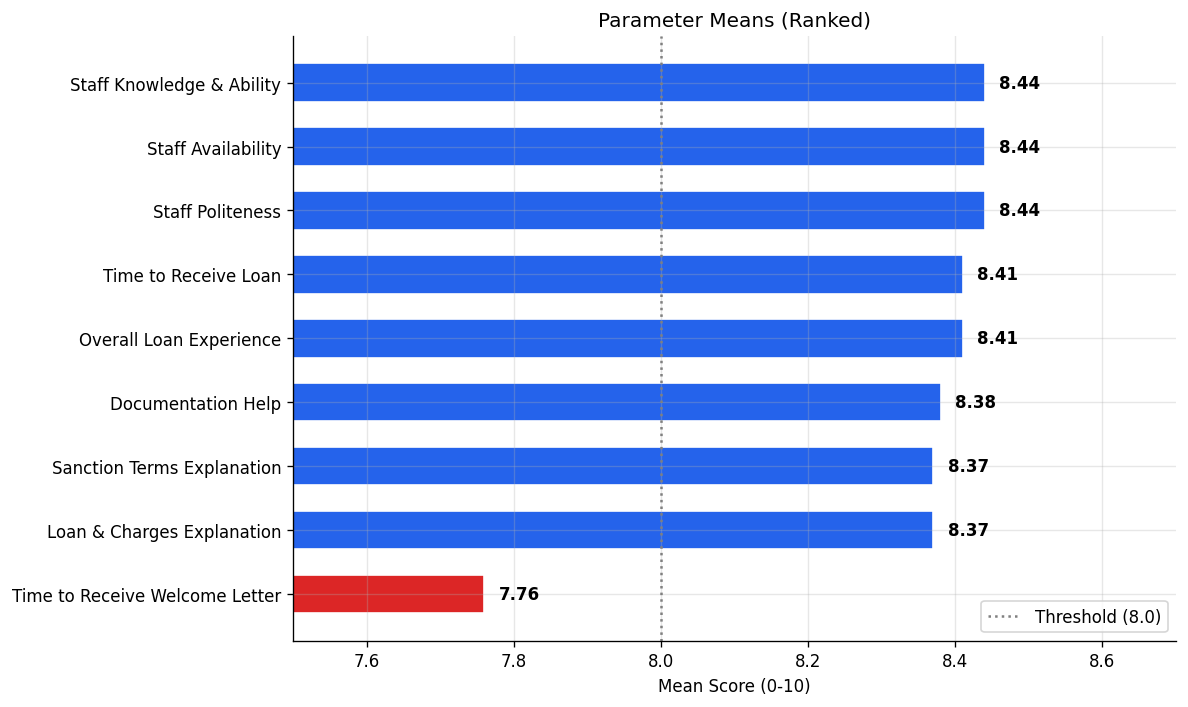

In [ ]:
# Visualization
param_means_sorted = df[params].mean().sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#DC2626' if v < 8.0 else '#2563EB' for v in param_means_sorted.values]
ax.barh([param_names[p] for p in param_means_sorted.index],
        param_means_sorted.values, color=colors, edgecolor='white', height=0.6)
ax.axvline(8.0, color='gray', linestyle=':', label='Threshold (8.0)')
for i, v in enumerate(param_means_sorted.values):
    ax.text(v + 0.02, i, f'{v:.2f}', va='center', fontweight='bold')
ax.set_xlabel('Mean Score (0-10)')
ax.set_title('Parameter Means (Ranked)')
ax.set_xlim(7.5, 8.7)
ax.legend()
plt.tight_layout()
plt.show()

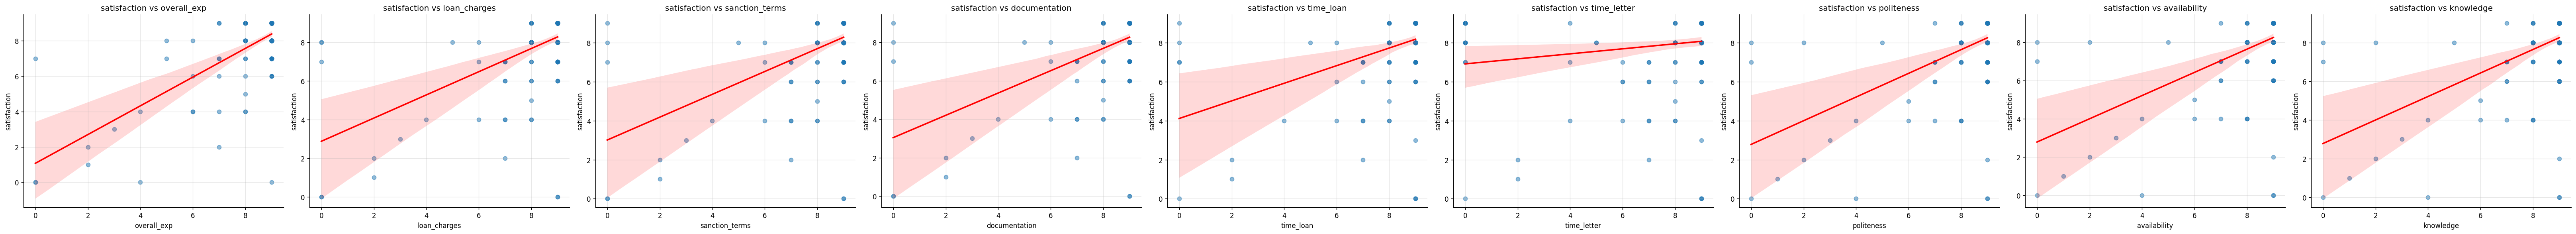

In [ ]:
def scatter_with_regression(df, target_col, feature_cols):
    plt.figure(figsize=(6 * len(feature_cols), 5))

    for i, col in enumerate(feature_cols):
        plt.subplot(1, len(feature_cols), i + 1)

        sns.regplot(
            data=df,
            x=col,
            y=target_col,
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red'}
        )

        plt.title(f'{target_col} vs {col}')
        plt.xlabel(col)
        plt.ylabel(target_col)

    plt.tight_layout()
    plt.show()


# Example usage:
features = params
scatter_with_regression(df, 'satisfaction', features)

**Q3 Inference:**
- **Doing Well (≥ 8.3):** Staff Politeness/Availability/Knowledge (8.44), Overall Experience (8.41), Time to Receive Loan (8.41), Documentation/Charges/Terms (~8.37)
- **Needs Improvement (< 8.0):** Time to Receive Welcome Letter **(7.76)** — the only sub-8.0 parameter, and also has the highest standard deviation (2.43), indicating high inconsistency

This maps to the SERVQUAL framework (Parasuraman et al., 1988): "Responsiveness" (staff) is strong, but "Reliability" (welcome letter delivery) is the weak link.

---

## 7. Q4 — Executive Summary (Recommendation Slide)

*Assuming we are the research agency presenting to Brand Y's management.*

In [ ]:
print("""
============================================================
  BRAND Y LOAN SERVICES — CSAT EXECUTIVE SUMMARY
============================================================

  HEADLINE METRICS
  ────────────────
  Mean Satisfaction:   7.91 / 10
  Net Promoter Score:  +39.5 (Great)
  Top-2-Box (Sat):     81.0%
  Detractor Rate:      10.5%

  STRENGTHS
  ─────────
  • Staff quality is #1 rated dimension (8.44/10)
  • South zone delivers world-class NPS (+61.5)
  • Loan processing speed meets expectations (8.41)
  • 81% of customers rate satisfaction at 8 or above

  CONCERNS
  ────────
  • Welcome letter delivery is the only sub-8.0 parameter (7.76)
  • North zone detractor rate (19.1%) is 2× the average
  • 39.5% passive segment = vulnerable to competitive churn

  PRIORITIES
  ──────────
  1. Fix welcome letter process (operational quick win)
  2. North zone recovery programme (reduce detractors <10%)
  3. Passive-to-promoter conversion (target NPS 50+)
  4. Replicate South zone best practices across all zones
============================================================
""")


  BRAND Y LOAN SERVICES — CSAT EXECUTIVE SUMMARY

  HEADLINE METRICS
  ────────────────
  Mean Satisfaction:   7.91 / 10
  Net Promoter Score:  +39.5 (Great)
  Top-2-Box (Sat):     81.0%
  Detractor Rate:      10.5%

  STRENGTHS
  ─────────
  • Staff quality is #1 rated dimension (8.44/10)
  • South zone delivers world-class NPS (+61.5)
  • Loan processing speed meets expectations (8.41)
  • 81% of customers rate satisfaction at 8 or above

  CONCERNS
  ────────
  • Welcome letter delivery is the only sub-8.0 parameter (7.76)
  • North zone detractor rate (19.1%) is 2× the average
  • 39.5% passive segment = vulnerable to competitive churn

  PRIORITIES
  ──────────
  1. Fix welcome letter process (operational quick win)
  2. North zone recovery programme (reduce detractors <10%)
  3. Passive-to-promoter conversion (target NPS 50+)
  4. Replicate South zone best practices across all zones



---

## 8. Q5 — T-Test: Satisfaction vs Each Parameter

**Method:** Paired-sample t-test (same respondent rated both satisfaction AND each parameter)

**Hypotheses:**
- H₀: μ_satisfaction = μ_parameter (no difference)
- H₁: μ_satisfaction ≠ μ_parameter (two-tailed)
- α = 0.05

**Why paired?** Each row is one respondent who answered ALL questions, so the scores are naturally paired. A paired test is more powerful because it controls for individual-level variation.

We also compute **Cohen's d** for effect size: Small < 0.2, Medium 0.2–0.8, Large > 0.8 (Cohen, 1988).

In [ ]:
print(f"{'Parameter':<35} {'Param Mean':>10} {'Diff':>7} {'t-stat':>8} {'p-value':>10} {'Cohen d':>8} {'Sig?':>8}")
print("-" * 95)

for p in params:
    diff = df['satisfaction'] - df[p]
    t_stat, p_val = ttest_rel(df['satisfaction'], df[p])
    d = diff.mean() / diff.std()  # Cohen's d for paired data
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'

    print(f"  {param_names[p]:<33} {df[p].mean():>10.2f} {diff.mean():>+7.2f} {t_stat:>8.3f} {p_val:>10.6f} {d:>+8.3f} {sig:>8}")

Parameter                           Param Mean    Diff   t-stat    p-value  Cohen d     Sig?
-----------------------------------------------------------------------------------------------
  Overall Loan Experience                 8.41   -0.50   -5.378   0.000000   -0.380      ***
  Loan & Charges Explanation              8.37   -0.46   -4.003   0.000088   -0.283      ***
  Sanction Terms Explanation              8.37   -0.46   -3.936   0.000115   -0.278      ***
  Documentation Help                      8.38   -0.47   -3.999   0.000090   -0.283      ***
  Time to Receive Loan                    8.41   -0.50   -3.776   0.000211   -0.267      ***
  Time to Receive Welcome Letter          7.76   +0.15    0.722   0.470836   +0.051       ns
  Staff Politeness                        8.44   -0.53   -4.576   0.000008   -0.324      ***
  Staff Availability                      8.44   -0.53   -4.576   0.000008   -0.324      ***
  Staff Knowledge & Ability               8.44   -0.53   -4.576   0

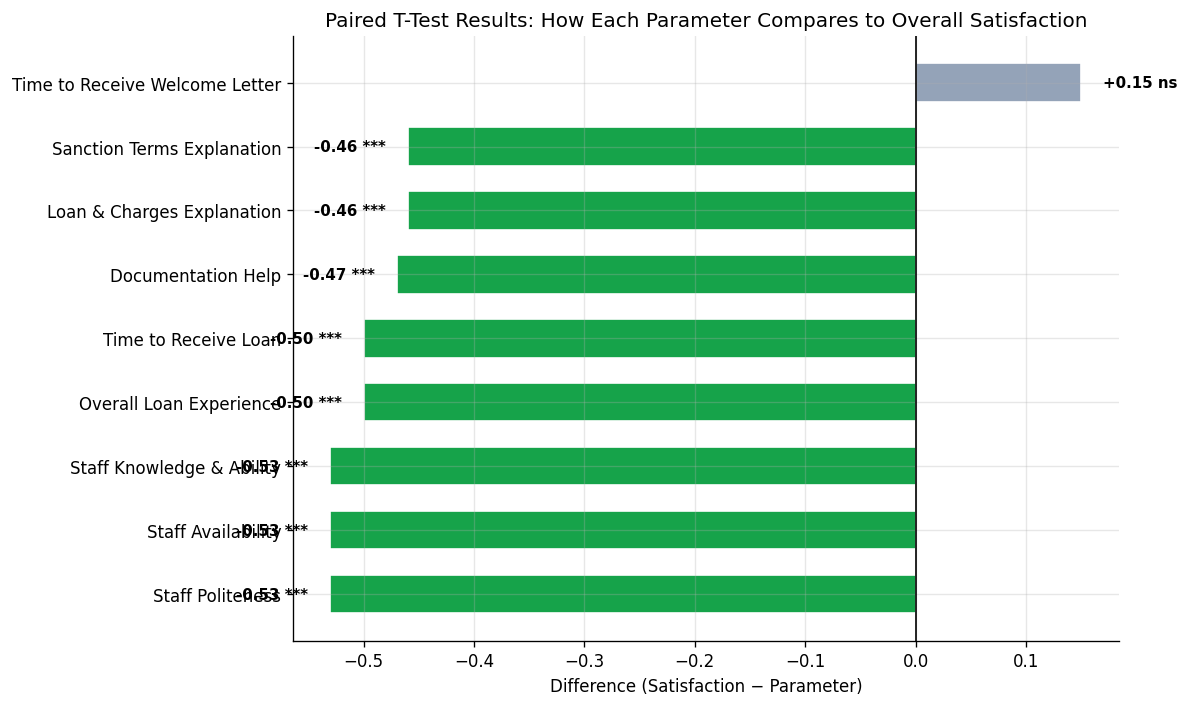

In [ ]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
diffs = [(param_names[p], (df['satisfaction'] - df[p]).mean(),
          ttest_rel(df['satisfaction'], df[p])[1]) for p in params]
diffs.sort(key=lambda x: x[1])

labels = [d[0] for d in diffs]
values = [d[1] for d in diffs]
colors = ['#16A34A' if d[2] < 0.05 else '#94A3B8' for d in diffs]

ax.barh(labels, values, color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=1)
for i, (label, val, pval) in enumerate(diffs):
    sig = '***' if pval < 0.001 else 'ns'
    ax.text(val - 0.02 if val < 0 else val + 0.02, i,
            f'{val:+.2f} {sig}', va='center',
            ha='right' if val < 0 else 'left', fontweight='bold', fontsize=9)
ax.set_xlabel('Difference (Satisfaction − Parameter)')
ax.set_title('Paired T-Test Results: How Each Parameter Compares to Overall Satisfaction')
plt.tight_layout()
plt.show()

**Q5 Inference:**
- **8 of 9 parameters** score significantly HIGHER than overall satisfaction (all p < 0.001)
- This means customers rate individual touchpoints well, but their holistic satisfaction is lower — a "global evaluation discount" (Oliver, 1980)
- **Exception:** "Time to receive welcome letter" is NOT significantly different (p = 0.47) — its low mean (7.76) matches overall satisfaction (7.91), making it the anchor dragging scores down
- Effect sizes are small (|d| < 0.4), so while statistically significant, the practical gap is modest

---

## 9. Q6 — Correlation Between Satisfaction and Parameters

**Method:** Pearson's r (linear) and Spearman's ρ (rank-order, non-parametric)

Both are computed for robustness since the data is non-normal. Agreement between Pearson and Spearman strengthens confidence in the results.

In [ ]:
print(f"{'Parameter':<35} {'Pearson r':>10} {'R²':>6} {'Spearman ρ':>11} {'p-value':>10}")
print("-" * 75)

corr_results = []
for p in params:
    r_pearson, p_pearson = pearsonr(df['satisfaction'], df[p])
    r_spearman, p_spearman = spearmanr(df['satisfaction'], df[p])
    corr_results.append({'param': p, 'pearson': r_pearson, 'r2': r_pearson**2, 'spearman': r_spearman})
    print(f"  {param_names[p]:<33} {r_pearson:>+10.4f} {r_pearson**2:>6.3f} {r_spearman:>+11.4f} {p_pearson:>10.6f}")

corr_df = pd.DataFrame(corr_results)

Parameter                            Pearson r     R²  Spearman ρ    p-value
---------------------------------------------------------------------------
  Overall Loan Experience              +0.7017  0.492     +0.4714   0.000000
  Loan & Charges Explanation           +0.5736  0.329     +0.5401   0.000000
  Sanction Terms Explanation           +0.5590  0.312     +0.5187   0.000000
  Documentation Help                   +0.5535  0.306     +0.5037   0.000000
  Time to Receive Loan                 +0.4198  0.176     +0.4892   0.000000
  Time to Receive Welcome Letter       +0.1926  0.037     +0.3810   0.006291
  Staff Politeness                     +0.5424  0.294     +0.4821   0.000000
  Staff Availability                   +0.5424  0.294     +0.4821   0.000000
  Staff Knowledge & Ability            +0.5424  0.294     +0.4821   0.000000


### Scatter Plot — Strongest Predictor

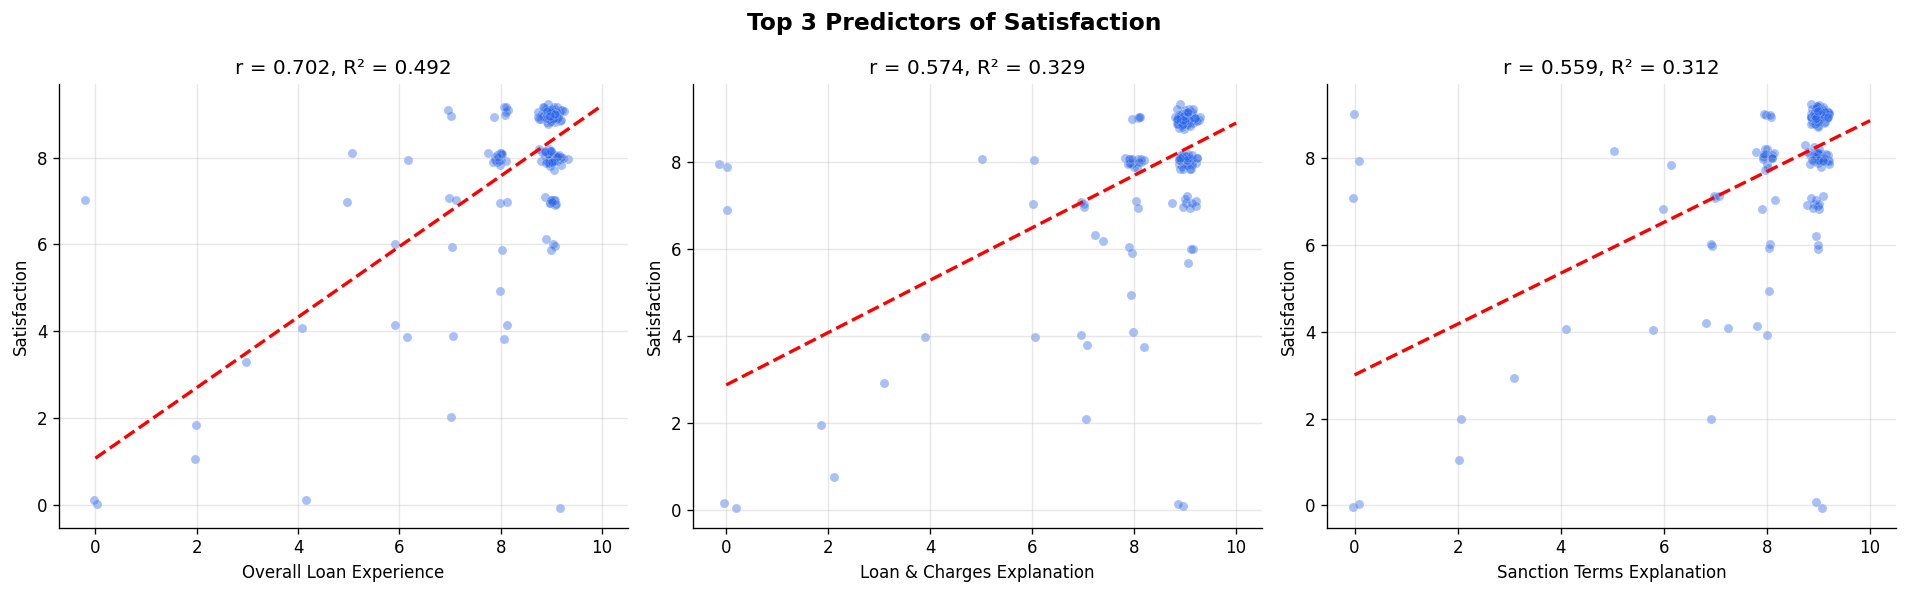

In [ ]:
# Scatter plot for top 3 correlates
top3 = corr_df.head(3)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (_, row) in zip(axes, top3.iterrows()):
    col = row['param']
    x = df[col] + np.random.normal(0, 0.1, len(df))  # jitter
    y = df['satisfaction'] + np.random.normal(0, 0.1, len(df))
    ax.scatter(x, y, alpha=0.4, s=30, color='#2563EB', edgecolors='white', linewidth=0.3)

    # Regression line
    z = np.polyfit(df[col], df['satisfaction'], 1)
    ax.plot([0, 10], [z[1], z[1]+10*z[0]], color='red', linewidth=2, linestyle='--')

    ax.set_xlabel(param_names[col])
    ax.set_ylabel('Satisfaction')
    ax.set_title(f"r = {row['pearson']:.3f}, R² = {row['r2']:.3f}")

plt.suptitle('Top 3 Predictors of Satisfaction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### OLS Regression — Best Predictor

Mutiple var Regression

In [ ]:

# Independent variables (all service parameters)
X = df[params]   # or df.drop(columns=['satisfaction'])

# Dependent variable
y = df['satisfaction']

# Add constant (intercept)
X = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X).fit()

# Print full summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           satisfaction   R-squared:                       0.505
Model:                            OLS   Adj. R-squared:                  0.487
Method:                 Least Squares   F-statistic:                     27.98
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           2.57e-26
Time:                        12:22:28   Log-Likelihood:                -330.48
No. Observations:                 200   AIC:                             677.0
Df Residuals:                     192   BIC:                             703.3
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.9682      0.564      1.

In [ ]:

coeffs = model.params.drop('const')

# sort by absolute influence
importance = coeffs.abs().sort_values(ascending=False)

print("Feature importance (by absolute coefficient):")
print(importance)

Feature importance (by absolute coefficient):
overall_exp       0.902385
sanction_terms    0.355284
documentation     0.281665
loan_charges      0.151239
time_loan         0.136301
knowledge         0.089694
politeness        0.089694
availability      0.089694
time_letter       0.022554
dtype: float64


scaled version

In [ ]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import pandas as pd

X = df[params].copy()
y = df['satisfaction']

# Remove constant columns
X = X.loc[:, X.nunique() > 1]

# Standardize and KEEP structure
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# Add constant
X_scaled = sm.add_constant(X_scaled)

# Fit model
model = sm.OLS(y, X_scaled).fit()

# Extract coefficients safely
std_coeffs = model.params.drop('const')

print("\n=== Driver Importance ===\n")
print(std_coeffs.sort_values(key=abs, ascending=False))


=== Driver Importance ===

overall_exp       1.398522
sanction_terms   -0.608471
documentation     0.481771
loan_charges      0.259016
time_loan         0.227338
knowledge        -0.143689
availability     -0.143689
politeness       -0.143689
time_letter      -0.060572
dtype: float64


Ordinal logistic regression


In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.preprocessing import StandardScaler

# Features and target
X = df[params].copy()
y = df['satisfaction']

# Remove constant columns
X = X.loc[:, X.nunique() > 1]

# (Optional but recommended) standardize predictors
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# Fit ordinal logistic regression
model = OrderedModel(
    y,
    X_scaled,
    distr='logit'   # logistic link (most common)
)

result = model.fit(method='bfgs')

# Summary
print(result.summary())

Optimization terminated successfully.
         Current function value: 1.161450
         Iterations: 72
         Function evaluations: 74
         Gradient evaluations: 74
                             OrderedModel Results                             
Dep. Variable:           satisfaction   Log-Likelihood:                -232.29
Model:                   OrderedModel   AIC:                             500.6
Method:            Maximum Likelihood   BIC:                             559.9
Date:                Fri, 24 Apr 2026                                         
Time:                        12:22:36                                         
No. Observations:                 200                                         
Df Residuals:                     182                                         
Df Model:                           9                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


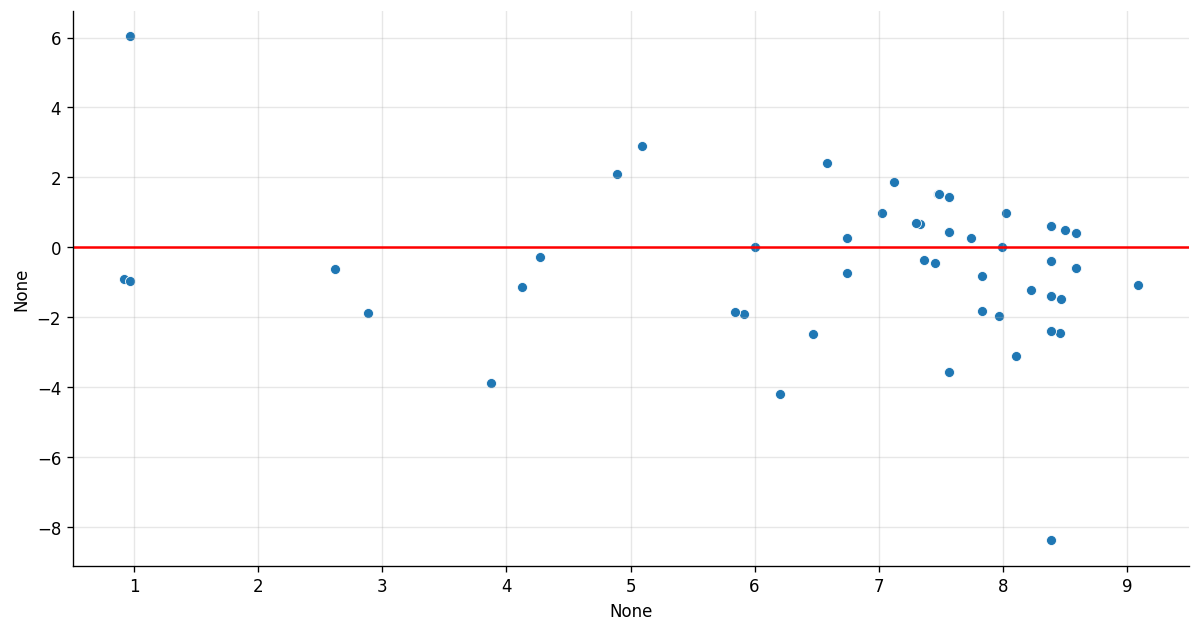

In [ ]:
X = sm.add_constant(df[params])
model = sm.OLS(df['satisfaction'], X).fit()

residuals = model.resid
fitted = model.fittedvalues

sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red')
plt.show()

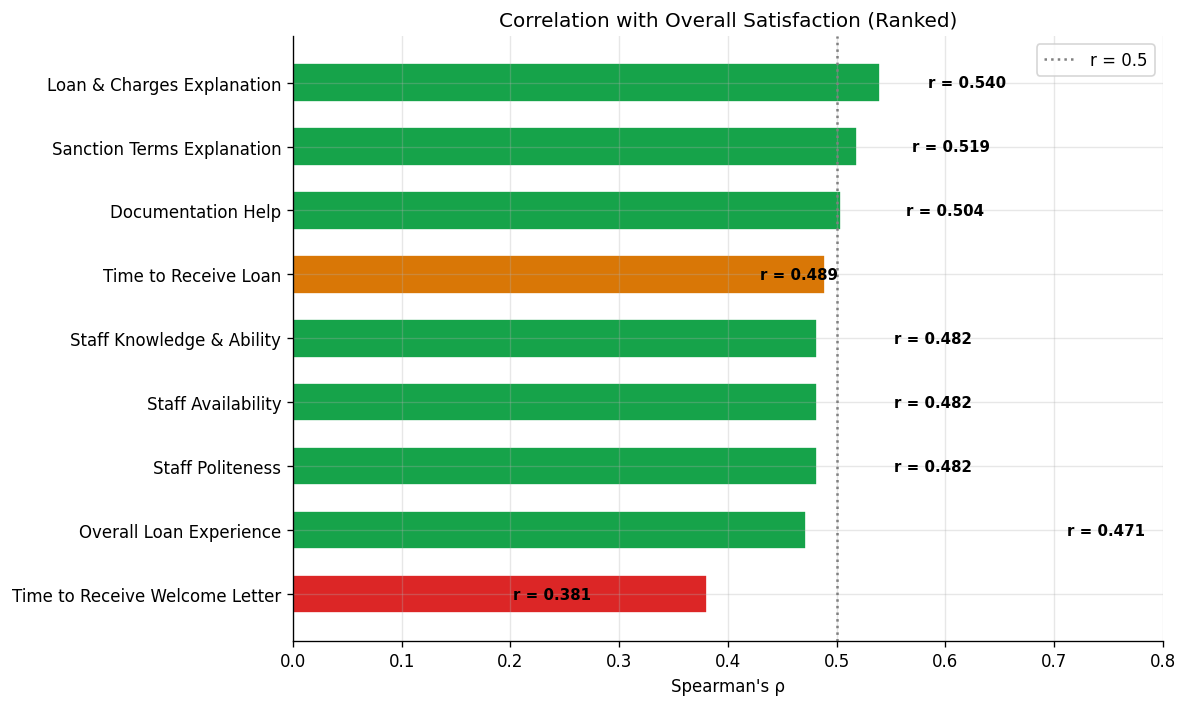

In [ ]:
# Correlation ranking chart
fig, ax = plt.subplots(figsize=(10, 6))
sorted_corr = corr_df.sort_values('spearman')
colors = ['#DC2626' if r < 0.3 else '#D97706' if r < 0.5 else '#16A34A' for r in sorted_corr['pearson']]
ax.barh([param_names[p] for p in sorted_corr['param']], sorted_corr['spearman'],
        color=colors, edgecolor='white', height=0.6)
for i, (_, row) in enumerate(sorted_corr.iterrows()):
    ax.text(row['pearson'] + 0.01, i, f"r = {row['spearman']:.3f}", va='center', fontweight='bold', fontsize=9)
ax.axvline(0.5, color='gray', linestyle=':', label='r = 0.5')
ax.set_xlabel("Spearman's ρ")
ax.set_title('Correlation with Overall Satisfaction (Ranked)')
ax.set_xlim(0, 0.8)
ax.legend()
plt.tight_layout()
plt.show()

**Q6 Inference:**
- **Strongest driver:** Overall Loan Experience (r = 0.70, R² = 0.49) — alone explains ~49% of satisfaction variance
- **Process cluster:** Loan charges, sanction terms, documentation (r ≈ 0.55–0.57)
- **Staff cluster:** Politeness, availability, knowledge (r ≈ 0.54)
- **Weakest:** Time to receive welcome letter (r = 0.19) — has the lowest mean BUT also the weakest correlation, meaning fixing it won't directly boost satisfaction scores much. However, it may be a "hygiene factor" (Herzberg, 1959) — its absence causes dissatisfaction even if its presence doesn't drive delight.

---

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel



# Define dependent and independent variables
y = df['satisfaction']
X = df[params]

# Fit ordinal logistic regression
model = OrderedModel(y, X, distr='logit')
result = model.fit()

print(result.summary())

                             OrderedModel Results                             
Dep. Variable:           satisfaction   Log-Likelihood:                -258.78
Model:                   OrderedModel   AIC:                             553.6
Method:            Maximum Likelihood   BIC:                             612.9
Date:                Fri, 24 Apr 2026                                         
Time:                        12:49:26                                         
No. Observations:                 200                                         
Df Residuals:                     182                                         
Df Model:                           9                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
overall_exp        0.1454        nan        nan        nan         nan         nan
loan_charges       0.0240        nan    

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 10. Q7 — Strategic Recommendations

Based on the complete analysis, here are prioritised recommendations for Brand Y.

### Priority Matrix: Impact × Performance

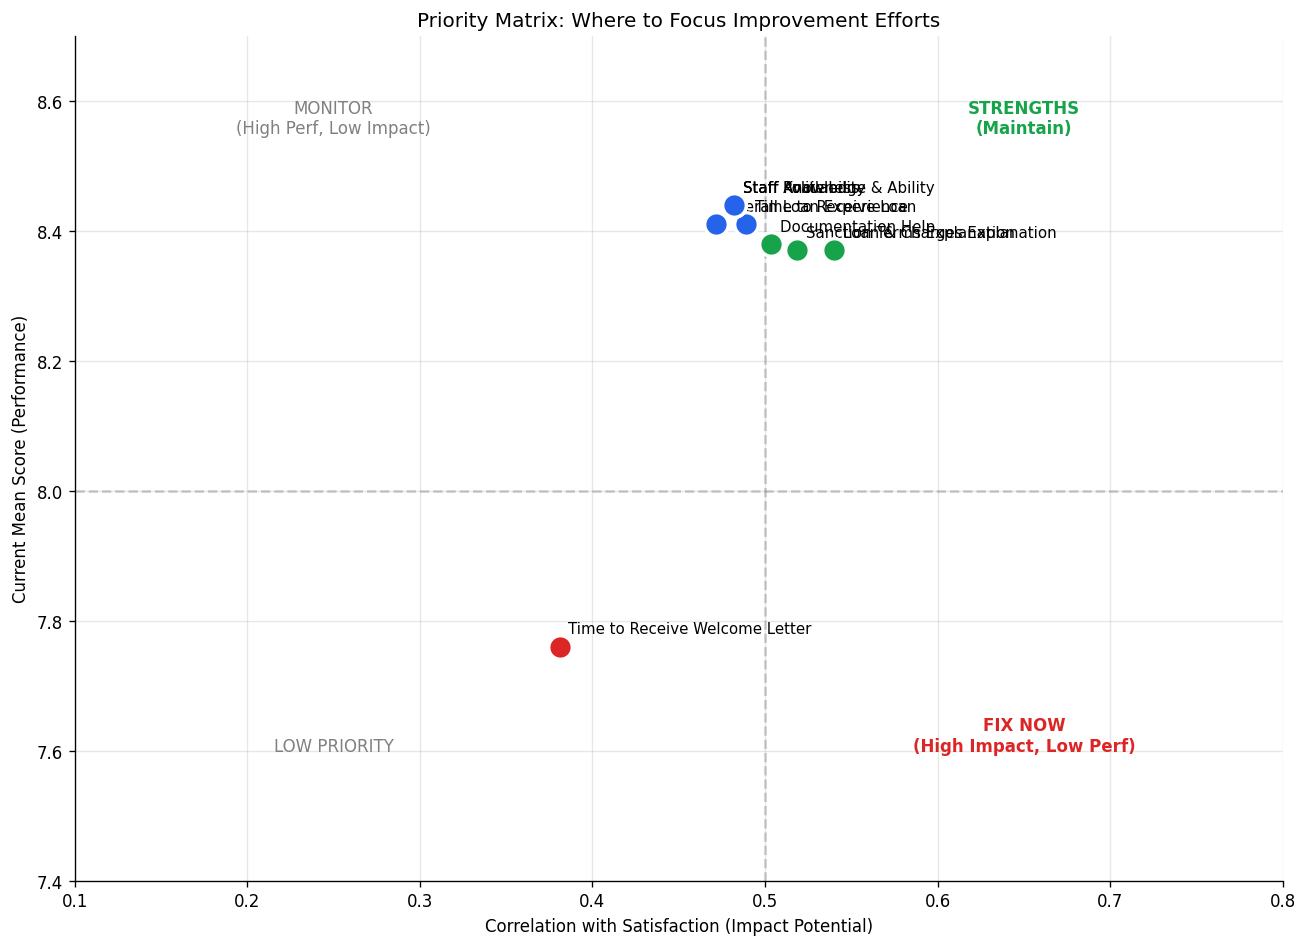

In [ ]:
fig, ax = plt.subplots(figsize=(11, 8))

for p in params:
    mean = df[p].mean()
    r, _ = spearmanr(df['satisfaction'], df[p])
    color = '#DC2626' if mean < 8.0 else '#16A34A' if r > 0.5 else '#2563EB'
    ax.scatter(r, mean, s=200, color=color, edgecolors='white', linewidth=2, zorder=5)
    ax.annotate(param_names[p], (r, mean), xytext=(5, 8),
                textcoords='offset points', fontsize=9)

ax.axhline(8.0, color='gray', linestyle='--', alpha=0.4)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.4)
ax.text(0.25, 8.55, 'MONITOR\n(High Perf, Low Impact)', ha='center', fontsize=10, color='gray')
ax.text(0.65, 8.55, 'STRENGTHS\n(Maintain)', ha='center', fontsize=10, color='#16A34A', fontweight='bold')
ax.text(0.25, 7.6, 'LOW PRIORITY', ha='center', fontsize=10, color='gray')
ax.text(0.65, 7.6, 'FIX NOW\n(High Impact, Low Perf)', ha='center', fontsize=10, color='#DC2626', fontweight='bold')
ax.set_xlabel('Correlation with Satisfaction (Impact Potential)')
ax.set_ylabel('Current Mean Score (Performance)')
ax.set_title('Priority Matrix: Where to Focus Improvement Efforts')
ax.set_xlim(0.1, 0.8)
ax.set_ylim(7.4, 8.7)
plt.tight_layout()
plt.show()

### Recommendations (Ranked by Priority)

**🔴 HIGH PRIORITY**

1. **Optimise End-to-End Loan Processing Experience**
   - Strongest satisfaction driver (r=0.70). A 1-point improvement here → ~0.74 points in satisfaction.
   - Focus: process mapping, bottleneck elimination, concierge pathway for complex cases.

2. **Fix Welcome Letter Delivery**
   - Only sub-8.0 parameter (7.76). It's a broken "hygiene factor" — its failure creates negative last impressions.
   - Action: automate dispatch within 48 hours of disbursement. Target: 8.0+ within one quarter.

3. **North Zone Recovery Programme**
   - 19.1% detractors (vs 10.5% average), lowest NPS (+25.5).
   - Action: qualitative deep-dives with 10–15 detractors, dedicated quality manager, 90-day target to halve detractor rate.

**🟡 MEDIUM PRIORITY**

4. **Passive-to-Promoter Conversion**
   - 39.5% passives = the largest conversion opportunity. Per Reichheld (2003), passives churn at 3× the rate of promoters.
   - Action: proactive post-disbursement check-ins, personalised follow-ups, loyalty programme.

5. **Replicate South Zone Best Practices**
   - South delivers NPS +61.5 with only 6.2% detractors. What are they doing differently?
   - Action: internal benchmarking study → systematic rollout nationwide.

6. **Enhance Process Transparency**
   - Loan charges, sanction terms, and documentation form a "process transparency" cluster (r≈0.55).
   - Action: clearer documentation, explainer videos, digital tracking dashboard for loan status.

**🟢 LOW PRIORITY (Maintain)**

7. **Protect Staff Excellence** — highest-rated at 8.44. Continue investing in hiring, training, retention.

8. **Investigate the Satisfaction Gap** — all parameters outscore overall satisfaction. A follow-up qualitative study using laddering techniques could uncover hidden drivers.

---